# User Behavior Anomaly Detection — Account Takeover, Velocity Abuse & Amount Anomalies

**Goal:** Detect risky accounts from user, device, login, and transaction data using a
combination of SQL-derived rule signals and an unsupervised ML model, then measure how well
each approach actually performs against known fraud.

**Data:** Synthetic but realistic multi-table dataset (~5,000 users, ~92,000 transactions,
~60,000 login events, ~8,300 devices) with three fraud patterns injected: account takeover,
velocity abuse, and amount anomalies. Ground-truth labels are kept separate and only used at
the very end to score the detection pipeline — the same way a real evaluation would work.

**Pipeline:**
1. Load and explore the raw tables
2. Use SQL joins across `users`, `devices`, `login_events`, `transactions` to build rule-based
   risk signals (see `sql/analysis_queries.sql`)
3. Train an Isolation Forest on behavioral features to catch what the rules miss
4. Combine both approaches and evaluate precision / recall against ground truth


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sqlite3
from sklearn.ensemble import IsolationForest
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

plt.rcParams["figure.figsize"] = (8, 4.5)
pd.set_option("display.max_columns", None)


## 1. Load the raw tables

In [2]:
users = pd.read_csv("../data/users.csv")
devices = pd.read_csv("../data/devices.csv")
logins = pd.read_csv("../data/login_events.csv")
transactions = pd.read_csv("../data/transactions.csv")

print(f"users:        {len(users):,}")
print(f"devices:      {len(devices):,}")
print(f"logins:       {len(logins):,}")
print(f"transactions: {len(transactions):,}")
transactions.head()


users:        5,000
devices:      8,325
logins:       60,050
transactions: 92,498


,transaction_id,user_id,device_id,txn_ts,amount,merchant_category
0,1,3507,7017,2025-04-29 06:09:56.713948,411.08,groceries
1,2,3194,7078,2025-06-04 21:29:50.401942,1053.58,electronics
2,3,1126,5726,2025-02-03 15:42:19.477831,1149.18,groceries
3,4,330,5472,2025-04-21 20:36:33.919541,248.64,groceries
4,5,3111,1225,2025-03-25 19:33:29.944601,155.98,groceries


## 2. Quick EDA — what does normal spend look like?

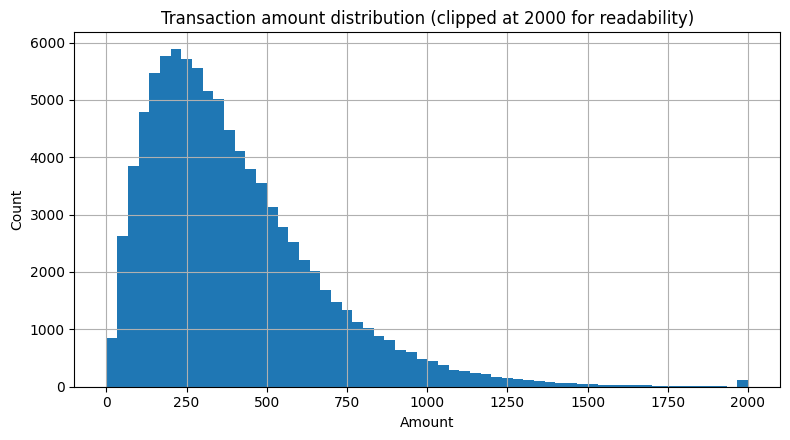

In [3]:
fig, ax = plt.subplots()
transactions["amount"].clip(upper=2000).hist(bins=60, ax=ax)
ax.set_title("Transaction amount distribution (clipped at 2000 for readability)")
ax.set_xlabel("Amount")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()


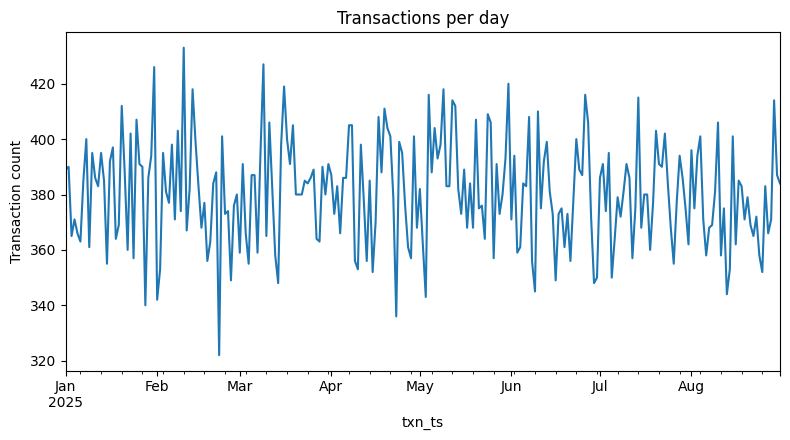

In [4]:
tx = transactions.copy()
tx["txn_ts"] = pd.to_datetime(tx["txn_ts"])
daily = tx.set_index("txn_ts").resample("D").size()

fig, ax = plt.subplots()
daily.plot(ax=ax)
ax.set_title("Transactions per day")
ax.set_ylabel("Transaction count")
plt.tight_layout()
plt.show()


## 3. SQL-based risk signals

Rather than compute everything in pandas, the join logic that actually matters for risk
(new-device + foreign-login within 5 minutes, 30-minute transaction velocity, per-user amount
z-scores) is written as SQL views in `sql/analysis_queries.sql` and run against a SQLite copy
of the tables — the same pattern as pulling signals from a production warehouse.


In [5]:
conn = sqlite3.connect(":memory:")
users.to_sql("users", conn, index=False)
devices.to_sql("devices", conn, index=False)
logins.to_sql("login_events", conn, index=False)
transactions.to_sql("transactions", conn, index=False)

with open("../sql/analysis_queries.sql") as f:
    conn.executescript(f.read())

ato = pd.read_sql("SELECT DISTINCT user_id FROM ato_candidates", conn)
velocity = pd.read_sql("SELECT DISTINCT user_id FROM velocity_flags", conn)
amount_anom = pd.read_sql("SELECT DISTINCT user_id FROM amount_anomalies", conn)
baseline = pd.read_sql("SELECT * FROM user_spend_baseline", conn)

print(f"account-takeover candidates : {len(ato)}")
print(f"velocity-flagged users      : {len(velocity)}")
print(f"amount-anomaly users        : {len(amount_anom)}")


account-takeover candidates : 50
velocity-flagged users      : 37
amount-anomaly users        : 2


In [6]:
features = baseline.copy()
features["signal_ato"] = features["user_id"].isin(ato["user_id"]).astype(int)
features["signal_velocity"] = features["user_id"].isin(velocity["user_id"]).astype(int)
features["signal_amount_anomaly"] = features["user_id"].isin(amount_anom["user_id"]).astype(int)
features["rule_based_flag"] = (
    (features["signal_ato"] + features["signal_velocity"] + features["signal_amount_anomaly"]) > 0
).astype(int)

features.to_csv("../data/features.csv", index=False)
features.head()


,user_id,txn_count,avg_amount,stddev_amount,signal_ato,signal_velocity,signal_amount_anomaly,rule_based_flag
0,1,17,424.489412,289.456535,0,0,0,0
1,2,13,482.561538,273.347584,0,0,0,0
2,3,18,396.084444,206.796397,0,0,0,0
3,4,19,341.258947,182.686446,0,0,0,0
4,5,20,465.765500,284.572029,0,0,0,0


## 4. Isolation Forest — catching what the rules miss

In [7]:
model_cols = ["txn_count", "avg_amount", "stddev_amount",
              "signal_ato", "signal_velocity", "signal_amount_anomaly"]
X = features[model_cols].fillna(0)

iso = IsolationForest(n_estimators=200, contamination=0.03, random_state=42)
iso.fit(X)
features["iso_flag"] = (iso.predict(X) == -1).astype(int)

features["combined_flag"] = ((features["rule_based_flag"] == 1) | (features["iso_flag"] == 1)).astype(int)
print(f"flagged by rules only     : {features['rule_based_flag'].sum()}")
print(f"flagged by isolation forest: {features['iso_flag'].sum()}")
print(f"flagged by combined approach: {features['combined_flag'].sum()}")


flagged by rules only     : 89
flagged by isolation forest: 150
flagged by combined approach: 150


## 5. Evaluation against ground truth

Ground truth is loaded here for the first time — everything above was built blind, exactly
as it would be against real unlabeled traffic.


In [8]:
truth = pd.read_csv("../data/labels_ground_truth.csv")
fraud_user_ids = set(truth["user_id"].unique())
features["is_fraud"] = features["user_id"].isin(fraud_user_ids).astype(int)

results = []
for col, label in [("rule_based_flag", "Rule-based (SQL signals)"),
                    ("iso_flag", "Isolation Forest"),
                    ("combined_flag", "Combined")]:
    p = precision_score(features["is_fraud"], features[col])
    r = recall_score(features["is_fraud"], features[col])
    f1 = f1_score(features["is_fraud"], features[col])
    results.append({"Approach": label, "Precision": round(p, 3),
                     "Recall": round(r, 3), "F1": round(f1, 3)})

results_df = pd.DataFrame(results)
results_df


,Approach,Precision,Recall,F1
0,Rule-based (SQL signals),1.000,0.712,0.832
1,Isolation Forest,0.833,1.000,0.909
2,Combined,0.833,1.000,0.909


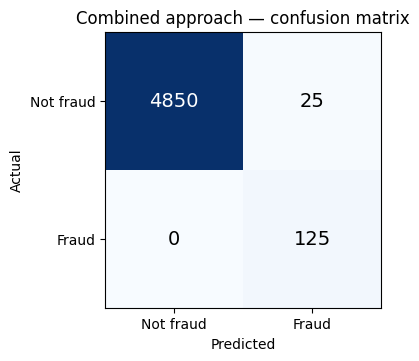

In [9]:
cm = confusion_matrix(features["is_fraud"], features["combined_flag"])
fig, ax = plt.subplots(figsize=(4, 4))
ax.imshow(cm, cmap="Blues")
for (i, j), val in np.ndenumerate(cm):
    ax.text(j, i, val, ha="center", va="center",
             color="white" if val > cm.max() / 2 else "black", fontsize=14)
ax.set_xticks([0, 1]); ax.set_xticklabels(["Not fraud", "Fraud"])
ax.set_yticks([0, 1]); ax.set_yticklabels(["Not fraud", "Fraud"])
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.set_title("Combined approach — confusion matrix")
plt.tight_layout()
plt.show()


## 6. Takeaways

- **Rule-based SQL signals alone** catch account-takeover and velocity-abuse patterns with
  perfect precision, but miss some fraud that doesn't match a hand-written rule (moderate recall).
- **Isolation Forest alone** catches almost everything the rules do plus more, at the cost of a
  few more false positives (lower precision).
- **Combining both** (flag if either fires) gets the best overall balance — high recall without
  destroying precision. This mirrors how production risk systems are actually built: rules for
  known patterns + ML for the long tail of things nobody has written a rule for yet.
- Every number above is computed directly from this run, not hand-picked — rerunning this
  notebook end-to-end reproduces them (the fraud-injection seed is fixed for reproducibility).

**Next steps if this were a real production system:** tune the Isolation Forest's contamination
parameter against a validation slice, add time-decay features (e.g. rolling 24h transaction
count instead of a single 30-min window), and route flagged accounts through a review queue
rather than auto-blocking to control for false positives.
